## Plotting the Signal Purposes

In [1]:
## Plot the signal from dataset_numpy files

import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from scipy.signal import butter, filtfilt
from scipy.interpolate import CubicSpline

In [2]:
TRIALS = "T3"
SUBJECT = "S41"
METHODS = "POS"
DATASET_PATH = f"../dataset_numpy/{SUBJECT}"
PPG_FS = 64
RPPG_FS = 35

In [3]:
### Define a function to process the data
def to_1d_float(signal: np.ndarray) -> np.ndarray:
    arr = np.asarray(signal, dtype=float).squeeze()
    if arr.ndim != 1:
        arr = arr.reshape(-1)
    return arr

def zscore(signal: np.ndarray) -> np.ndarray:
    signal = to_1d_float(signal)
    std = np.std(signal)
    if std < 1e-8:
        return signal - np.mean(signal)
    return (signal - np.mean(signal)) / std


def bandpass_filter(signal: np.ndarray, fs: int, low_hz: float = 0.7, high_hz: float = 2.5, order: int = 3) -> np.ndarray:
    signal = to_1d_float(signal)
    nyquist = 0.5 * fs
    low = low_hz / nyquist
    high = min(high_hz / nyquist, 0.99)
    b, a = butter(order, [low, high], btype="bandpass")
    return filtfilt(b, a, signal)


def preprocess_ppg(ppg_signal: np.ndarray, fs: int, target_len: int) -> np.ndarray:
    filtered = bandpass_filter(ppg_signal, fs)
    return zscore(filtered)


def preprocess_rppg(rppg_signal: np.ndarray, src_fs: int, dst_fs: int, target_len: int) -> np.ndarray:
    rppg_signal = to_1d_float(rppg_signal)
    duration = len(rppg_signal) / float(src_fs)

    t_src = np.linspace(0.0, duration, num=len(rppg_signal), endpoint=False)
    t_dst = np.linspace(0.0, duration, num=int(round(duration * dst_fs)), endpoint=False)

    spline = CubicSpline(t_src, rppg_signal, extrapolate=False)
    upsampled = spline(t_dst)
    if np.isnan(upsampled).any():
        upsampled = np.nan_to_num(upsampled, nan=float(np.nanmean(rppg_signal)))

    filtered = bandpass_filter(upsampled, dst_fs)
    return zscore(filtered)

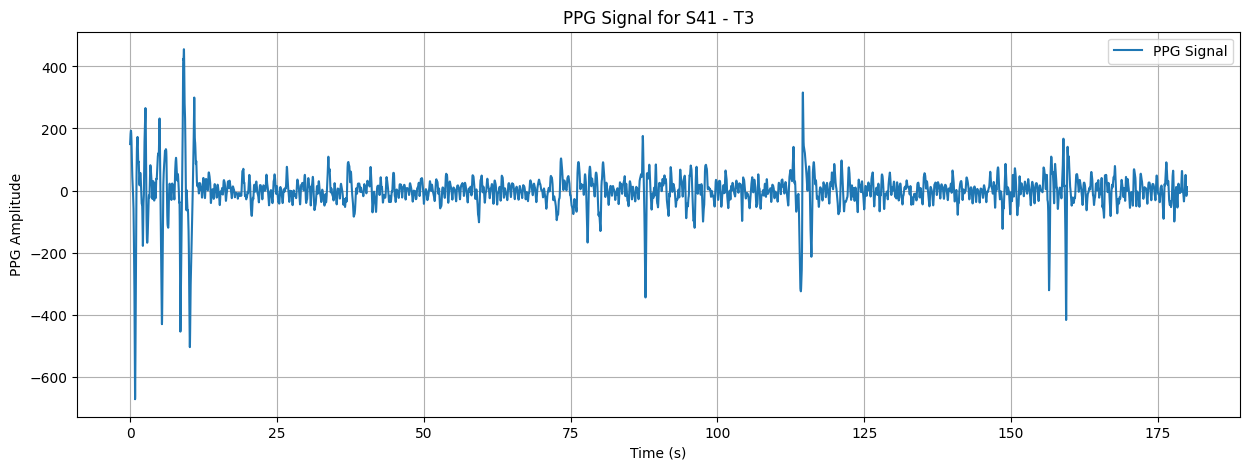

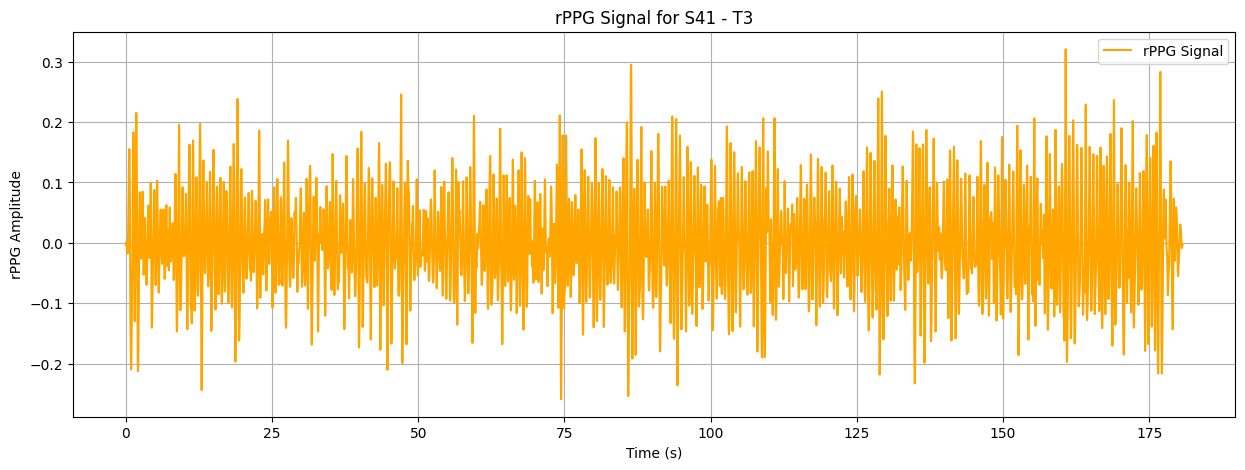

In [4]:
## Opening the dataset and plot 
ppg_signal = pd.read_csv(os.path.join(DATASET_PATH, f"bvp_{SUBJECT}_{TRIALS}.csv"))
ppg_time_axis = np.arange(len(ppg_signal)) / PPG_FS

plt.figure(figsize=(15, 5))
plt.plot(ppg_time_axis, ppg_signal, label='PPG Signal')
plt.title(f'PPG Signal for {SUBJECT} - {TRIALS}')
plt.xlabel('Time (s)')
plt.ylabel('PPG Amplitude')
plt.legend()
plt.grid()
plt.show()

# Plot the rPPG signal
rppg_signal = np.load(os.path.join(DATASET_PATH, f"{SUBJECT}_{TRIALS}_{METHODS}_rppg.npy"))
rppg_time_axis = np.arange(len(rppg_signal)) / RPPG_FS

plt.figure(figsize=(15, 5))
plt.plot(rppg_time_axis, rppg_signal, label='rPPG Signal', color='orange')
plt.title(f'rPPG Signal for {SUBJECT} - {TRIALS}')
plt.xlabel('Time (s)')
plt.ylabel('rPPG Amplitude')
plt.legend()
plt.grid()
plt.show()

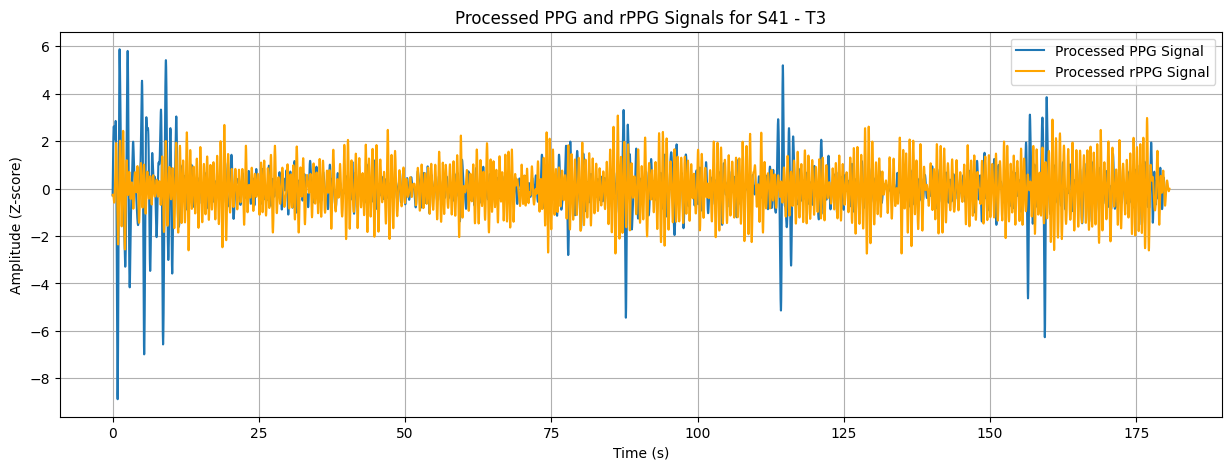

In [5]:
## Plot after the processing
processed_ppg = preprocess_ppg(ppg_signal, PPG_FS, target_len=len(ppg_signal))
processed_rppg = preprocess_rppg(rppg_signal, RPPG_FS, RPPG_FS, target_len=len(rppg_signal))

plt.figure(figsize=(15, 5))
plt.plot(ppg_time_axis, processed_ppg, label='Processed PPG Signal')
plt.plot(rppg_time_axis, processed_rppg, label='Processed rPPG Signal', color='orange')
plt.title(f'Processed PPG and rPPG Signals for {SUBJECT} - {TRIALS}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (Z-score)')
plt.legend()
plt.grid()
plt.show()